In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

In [2]:
df = pd.read_csv("data/processed/leakage_free_dataset.csv")

df.head()

,Vehicle_ID,Make_and_Model,Vehicle_Type,Year_of_Manufacture,Route_Info,Weather_Conditions,Road_Conditions,Communication_Interface,Telematics_Gateway,Edge_Device_Class,...,Days_Since_Last_Maintenance,Last_Maintenance_Date,Brake_Condition,Maintenance_Required,Pre_Event_Record,Data_Split,FL_Client_ID,Partition_Type,Local_Epochs_Per_Round,Communication_Rounds
0,1,1,4,2016,1,4,4,1,2,2,...,32,2024-11-30,0,0,1,1,1,0,2,200
1,2,0,2,2017,1,5,3,2,0,3,...,49,2024-11-13,0,0,1,0,1,0,2,200
2,3,3,3,2011,1,4,0,2,0,1,...,56,2024-11-06,1,0,1,1,2,0,2,200
3,4,4,0,2020,0,5,1,0,2,0,...,92,2024-10-01,1,0,1,1,3,0,2,200
4,5,4,1,2024,1,4,2,2,2,3,...,35,2024-11-27,1,0,1,1,4,0,2,200


In [3]:
df = df.drop(columns=["Last_Maintenance_Date"])

In [4]:
X = df.drop("Maintenance_Required", axis=1)

y = df["Maintenance_Required"]

print(X.shape)
print(y.shape)

(250000, 34)
(250000,)


In [5]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [6]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
26,Days_Since_Last_Maintenance,0.283761
24,Historical_Maintenance_Cost,0.132604
17,Vibration_Levels,0.128985
25,Impact_on_Efficiency,0.093320
16,Battery_Status,0.084667
15,Fuel_Consumption,0.065794
13,Engine_Temperature,0.054338
23,Sensor_Packet_Loss_Rate,0.054333
18,Oil_Quality,0.027001
22,CAN_Message_Rate_Hz,0.025627


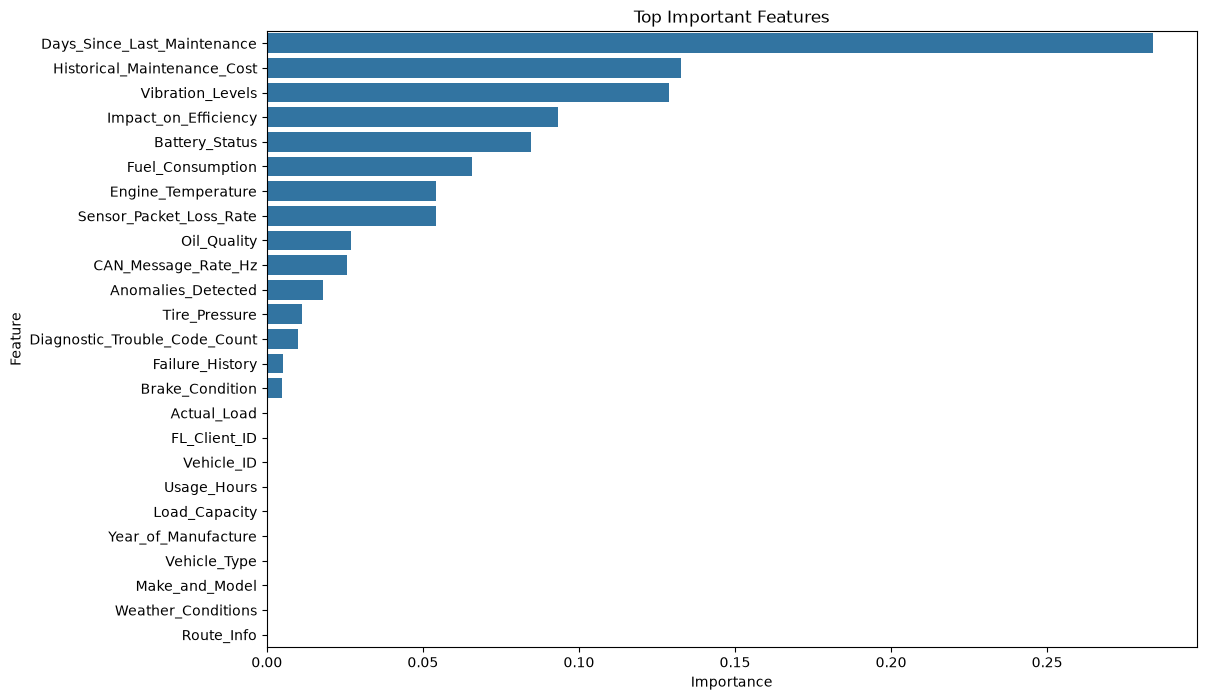

In [7]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance.head(25),
    x="Importance",
    y="Feature"
)

plt.title("Top Important Features")

plt.show()

In [8]:
mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi = pd.DataFrame({
    "Feature": X.columns,
    "Mutual Information": mi
})

mi = mi.sort_values(
    by="Mutual Information",
    ascending=False
)

mi

,Feature,Mutual Information
26,Days_Since_Last_Maintenance,0.610982
24,Historical_Maintenance_Cost,0.549450
25,Impact_on_Efficiency,0.498047
17,Vibration_Levels,0.466706
16,Battery_Status,0.457042
15,Fuel_Consumption,0.453173
18,Oil_Quality,0.453012
23,Sensor_Packet_Loss_Rate,0.390765
13,Engine_Temperature,0.381090
22,CAN_Message_Rate_Hz,0.339231


In [9]:
comparison = importance.merge(
    mi,
    on="Feature"
)

comparison

,Feature,Importance,Mutual Information
0,Days_Since_Last_Maintenance,0.283761,0.610982
1,Historical_Maintenance_Cost,0.132604,0.549450
2,Vibration_Levels,0.128985,0.466706
3,Impact_on_Efficiency,0.093320,0.498047
4,Battery_Status,0.084667,0.457042
5,Fuel_Consumption,0.065794,0.453173
6,Engine_Temperature,0.054338,0.381090
7,Sensor_Packet_Loss_Rate,0.054333,0.390765
8,Oil_Quality,0.027001,0.453012
9,CAN_Message_Rate_Hz,0.025627,0.339231


In [11]:
comparison.to_csv(
    "outputs/reports/feature_importance.csv",
    index=False
)

In [12]:
importance.head(25)


,Feature,Importance
26,Days_Since_Last_Maintenance,0.283761
24,Historical_Maintenance_Cost,0.132604
17,Vibration_Levels,0.128985
25,Impact_on_Efficiency,0.093320
16,Battery_Status,0.084667
15,Fuel_Consumption,0.065794
13,Engine_Temperature,0.054338
23,Sensor_Packet_Loss_Rate,0.054333
18,Oil_Quality,0.027001
22,CAN_Message_Rate_Hz,0.025627


In [13]:
selected_features = importance[
    importance["Importance"] >= 0.005
]["Feature"].tolist()

selected_features

['Days_Since_Last_Maintenance',
 'Historical_Maintenance_Cost',
 'Vibration_Levels',
 'Impact_on_Efficiency',
 'Battery_Status',
 'Fuel_Consumption',
 'Engine_Temperature',
 'Sensor_Packet_Loss_Rate',
 'Oil_Quality',
 'CAN_Message_Rate_Hz',
 'Anomalies_Detected',
 'Tire_Pressure',
 'Diagnostic_Trouble_Code_Count',
 'Failure_History']